🔴 RISK LAYER 4: PGA APPROVAL VALIDATION

Purpose: Identify shipments requiring PGA approval without obtained token
Regulatory Basis: Partner Government Agency (PGA) Requirements

📦 Analyzing 5,000 shipments...

📊 RESULTS:
   ┌─ Shipments requiring PGA approval: 982
   ├─ Missing PGA token (Skipped Validation): 115
   ├─ PGA Compliance Rate: 88.29%
   ├─ Overall Defect Rate: 2.30%
   └─ Total Value at Risk: $67,878,591.13

🔍 SAMPLE PGA FAILURES:

   ┌─ Shipment: EXP-100027
   ├─ Schedule B: 9030.90.0000
   ├─ PGA Required: Y (Yes)
   ├─ PGA Obtained: N (No)
   ├─ Business Unit: US-MedicalDevices
   ├─ Destination: SYRIA
   └─ Value: $1,104,316.80

   ┌─ Shipment: EXP-100118
   ├─ Schedule B: 8471.30.0100
   ├─ PGA Required: Y (Yes)
   ├─ PGA Obtained: N (No)
   ├─ Business Unit: US-ConsumerElectronics
   ├─ Destination: SG
   └─ Value: $684,377.72

   ┌─ Shipment: EXP-100122
   ├─ Schedule B: 9018.90.7500
   ├─ PGA Required: Y (Yes)
   ├─ PGA Obtained: N (No)
   ├─ Business Unit: US-Aer

,Business Unit,Total Shipments,PGA Failures,Total Value,Failure Rate %
0,US-AerospaceParts,735,24,4.713519e+08,3.27
1,US-ConsumerElectronics,1582,37,9.824572e+08,2.34
2,US-IndustrialEquipment,966,21,6.082091e+08,2.17
3,US-MedicalDevices,1239,25,8.121318e+08,2.02
4,US-Pharmaceuticals,478,8,2.948135e+08,1.67



📊 PGA FAILURES BY DESTINATION COUNTRY:


,Country,PGA Failures,Total Value
0,BE,19,10487452.47
5,SA,17,10842217.88
4,MX,15,9718292.50
8,TW,15,7291447.73
3,IN,13,9658051.89
6,SG,13,6197923.57
1,CN,12,7340514.35
2,IE,10,5238373.94
7,SYRIA,1,1104316.80



📅 MONTHLY PGA FAILURE RATE:


,PGA_Failures,Total_Shipments,PGA_Failure_Rate_Pct
shipment_month,,,
2025-07,6,349,1.72
2025-08,4,415,0.96
2025-09,10,401,2.49
2025-10,11,433,2.54
2025-11,15,430,3.49
2025-12,10,465,2.15
2026-01,10,384,2.60
2026-02,12,395,3.04
2026-03,6,402,1.49



📈 RECENT TREND (Last 6 months):
   2026-02:  3.04% ██████
   2026-03:  1.49% ██
   2026-04:  2.00% ████
   2026-05:  2.26% ████
   2026-06:  3.07% ██████
   2026-07:  1.08% ██


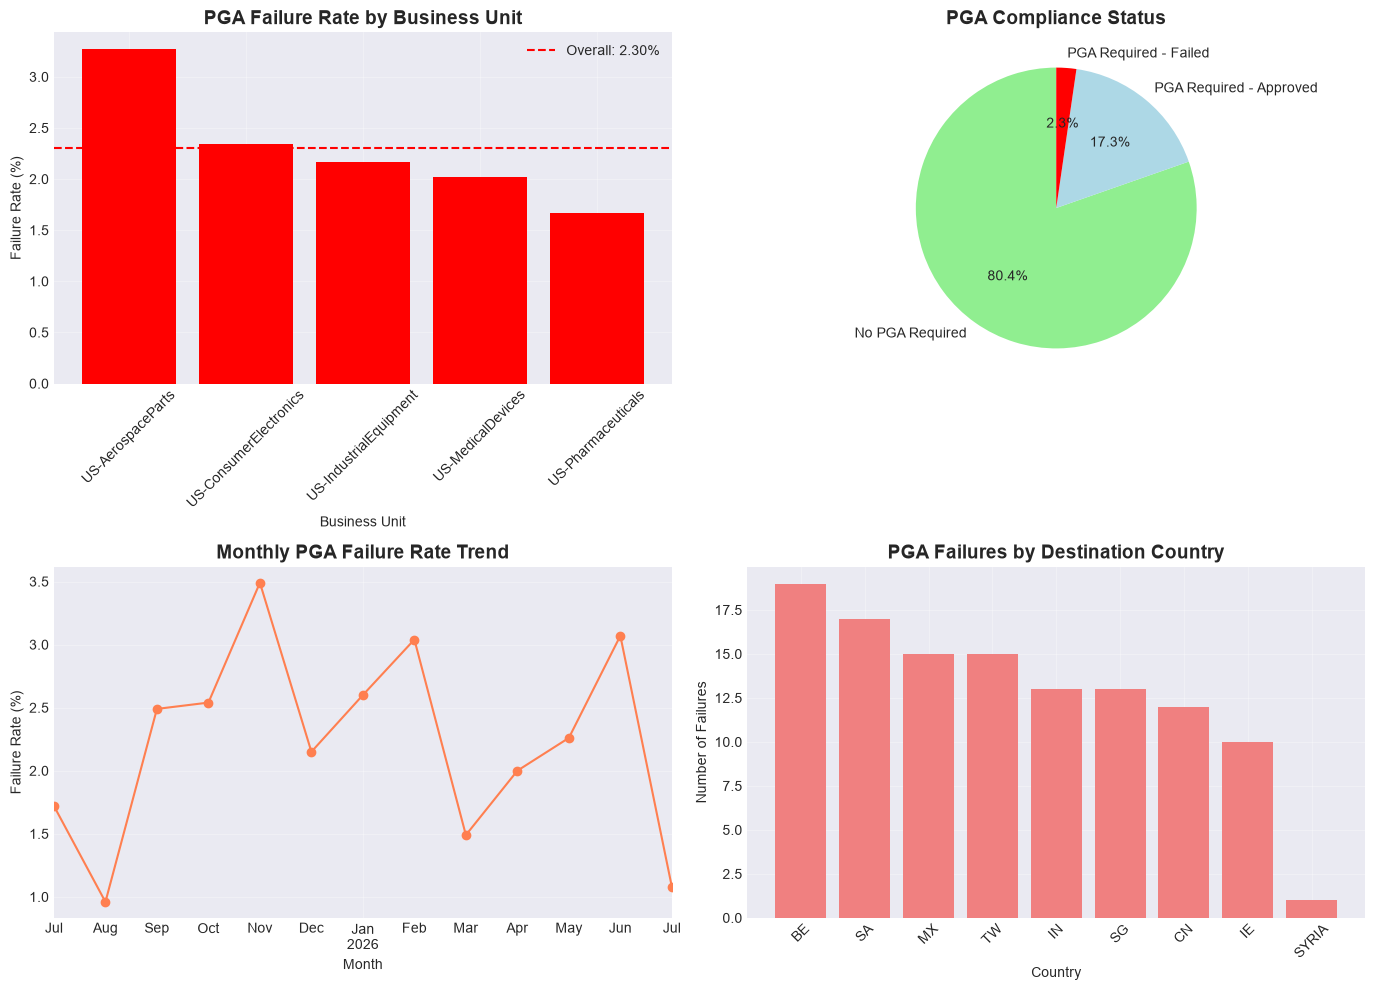


💾 Saved: output/risk_layer4_pga_approval.png

💾 Saved: us_export_compliance_data_layer4.csv

✅ RISK LAYER 4 COMPLETE!


In [1]:
# %% [markdown]
# # 🔴 Risk Layer 4: PGA Approval Validation
# 
# **Purpose**: Identify shipments requiring PGA approval without obtained token
# 
# **Regulatory Basis**: Partner Government Agency (PGA) Requirements
# 
# **Key Question**: Are we shipping items requiring PGA approval without getting it?

# %% [code]
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os

# Set style
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")

print("="*70)
print("🔴 RISK LAYER 4: PGA APPROVAL VALIDATION")
print("="*70)
print("\nPurpose: Identify shipments requiring PGA approval without obtained token")
print("Regulatory Basis: Partner Government Agency (PGA) Requirements")

# %% [code]
# Load dataset with previous layers
df = pd.read_csv('us_export_compliance_data_layer3.csv', parse_dates=['shipment_date', 'clearance_date'])

print(f"\n📦 Analyzing {len(df):,} shipments...")

# %% [markdown]
# ## PGA Approval Logic
# 
# **Rule**: If PGA is required, approval must be obtained
# - `pga_required == 'Y'` (PGA approval needed)
# - `pga_obtained == 'N'` (Approval not obtained)

# %% [code]
# Apply PGA approval logic
df['pga_compliance_failure'] = (
    (df['pga_required'] == 'Y') & 
    (df['pga_obtained'] == 'N')
)

# Count results
pga_failures = df['pga_compliance_failure'].sum()
pga_failure_rate = (pga_failures / len(df)) * 100
pga_required_count = len(df[df['pga_required'] == 'Y'])
pga_compliance_rate = ((pga_required_count - pga_failures) / pga_required_count * 100) if pga_required_count > 0 else 0
pga_total_value = df[df['pga_compliance_failure']]['total_value_usd'].sum()

print(f"\n📊 RESULTS:")
print(f"   ┌─ Shipments requiring PGA approval: {pga_required_count:,}")
print(f"   ├─ Missing PGA token (Skipped Validation): {pga_failures:,}")
print(f"   ├─ PGA Compliance Rate: {pga_compliance_rate:.2f}%")
print(f"   ├─ Overall Defect Rate: {pga_failure_rate:.2f}%")
print(f"   └─ Total Value at Risk: ${pga_total_value:,.2f}")

# %% [markdown]
# ## Examine PGA Failures

# %% [code]
if pga_failures > 0:
    print("\n🔍 SAMPLE PGA FAILURES:")
    sample_pga = df[df['pga_compliance_failure']][
        ['shipment_id', 'schedule_b_code', 'pga_required', 'pga_obtained', 
         'exporter_business_unit', 'consignee_country', 'total_value_usd']
    ].head(5)
    
    for idx, row in sample_pga.iterrows():
        print(f"\n   ┌─ Shipment: {row['shipment_id']}")
        print(f"   ├─ Schedule B: {row['schedule_b_code']}")
        print(f"   ├─ PGA Required: {row['pga_required']} (Yes)")
        print(f"   ├─ PGA Obtained: {row['pga_obtained']} (No)")
        print(f"   ├─ Business Unit: {row['exporter_business_unit']}")
        print(f"   ├─ Destination: {row['consignee_country']}")
        print(f"   └─ Value: ${row['total_value_usd']:,.2f}")

# %% [markdown]
# ## Analysis by Business Unit

# %% [code]
pga_by_bu = df.groupby('exporter_business_unit').agg({
    'shipment_id': 'count',
    'pga_compliance_failure': 'sum',
    'total_value_usd': 'sum'
}).reset_index()

pga_by_bu.columns = ['Business Unit', 'Total Shipments', 'PGA Failures', 'Total Value']
pga_by_bu['Failure Rate %'] = (pga_by_bu['PGA Failures'] / pga_by_bu['Total Shipments'] * 100).round(2)
pga_by_bu = pga_by_bu.sort_values('Failure Rate %', ascending=False)

print("\n📊 PGA FAILURES BY BUSINESS UNIT:")
display(pga_by_bu)

# %% [markdown]
# ## Analysis by Destination Country

# %% [code]
pga_by_country = df[df['pga_compliance_failure']].groupby('consignee_country').agg({
    'shipment_id': 'count',
    'total_value_usd': 'sum'
}).reset_index()

pga_by_country.columns = ['Country', 'PGA Failures', 'Total Value']
pga_by_country = pga_by_country.sort_values('PGA Failures', ascending=False)

print("\n📊 PGA FAILURES BY DESTINATION COUNTRY:")
display(pga_by_country.head(10))

# %% [markdown]
# ## Time-Based Analysis

# %% [code]
# Monthly PGA failure rate
df['shipment_month'] = df['shipment_date'].dt.to_period('M')
monthly_pga = df.groupby('shipment_month').agg({
    'pga_compliance_failure': ['sum', 'count']
}).round(4)

monthly_pga.columns = ['PGA_Failures', 'Total_Shipments']
monthly_pga['PGA_Failure_Rate_Pct'] = (monthly_pga['PGA_Failures'] / monthly_pga['Total_Shipments'] * 100).round(2)

print("\n📅 MONTHLY PGA FAILURE RATE:")
display(monthly_pga)

# Show trend
print("\n📈 RECENT TREND (Last 6 months):")
for month, row in monthly_pga.tail(6).iterrows():
    rate = row['PGA_Failure_Rate_Pct']
    bar = '█' * int(rate * 2)
    print(f"   {month}: {rate:5.2f}% {bar}")

# %% [markdown]
# ## Visualization

# %% [code]
# Create output folder if it doesn't exist
if not os.path.exists('output'):
    os.makedirs('output')
    print("✅ Created output folder")

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# 1. PGA failure rate by business unit
bu_pga_sorted = pga_by_bu.sort_values('Failure Rate %', ascending=False)
colors = ['red' if rate > 1 else 'orange' if rate > 0.5 else 'green' for rate in bu_pga_sorted['Failure Rate %']]
axes[0,0].bar(bu_pga_sorted['Business Unit'], bu_pga_sorted['Failure Rate %'], color=colors)
axes[0,0].set_title('PGA Failure Rate by Business Unit', fontsize=14, fontweight='bold')
axes[0,0].set_xlabel('Business Unit')
axes[0,0].set_ylabel('Failure Rate (%)')
axes[0,0].tick_params(axis='x', rotation=45)
axes[0,0].axhline(y=pga_failure_rate, color='red', linestyle='--', 
                  label=f'Overall: {pga_failure_rate:.2f}%')
axes[0,0].legend()
axes[0,0].grid(True, alpha=0.3)

# 2. PGA status distribution
pga_status = df.groupby('pga_required')['pga_compliance_failure'].sum()
pga_labels = ['No PGA Required', 'PGA Required - Approved', 'PGA Required - Failed']
pga_values = [
    len(df[df['pga_required'] == 'N']),
    len(df[(df['pga_required'] == 'Y') & (df['pga_compliance_failure'] == False)]),
    pga_failures
]
colors_pie = ['lightgreen', 'lightblue', 'red']
axes[0,1].pie(pga_values, labels=pga_labels, autopct='%1.1f%%', colors=colors_pie, startangle=90)
axes[0,1].set_title('PGA Compliance Status', fontsize=14, fontweight='bold')

# 3. Monthly trend
monthly_pga['PGA_Failure_Rate_Pct'].plot(kind='line', ax=axes[1,0], marker='o', color='coral')
axes[1,0].set_title('Monthly PGA Failure Rate Trend', fontsize=14, fontweight='bold')
axes[1,0].set_xlabel('Month')
axes[1,0].set_ylabel('Failure Rate (%)')
axes[1,0].grid(True, alpha=0.3)

# 4. PGA failures by country (top 10)
pga_country_sorted = pga_by_country.head(10)
axes[1,1].bar(pga_country_sorted['Country'], pga_country_sorted['PGA Failures'], color='lightcoral')
axes[1,1].set_title('PGA Failures by Destination Country', fontsize=14, fontweight='bold')
axes[1,1].set_xlabel('Country')
axes[1,1].set_ylabel('Number of Failures')
axes[1,1].tick_params(axis='x', rotation=45)
axes[1,1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('output/risk_layer4_pga_approval.png', dpi=300, bbox_inches='tight')
plt.show()

print("\n💾 Saved: output/risk_layer4_pga_approval.png")

# %% [code]
# Save the enhanced dataset
df.to_csv('us_export_compliance_data_layer4.csv', index=False)
print("\n💾 Saved: us_export_compliance_data_layer4.csv")

print("\n" + "="*70)
print("✅ RISK LAYER 4 COMPLETE!")
print("="*70)